# Wind Data Comparison between Models and Observations

This notebook downloads observational data at the following stations and compares model data (HRDPS and CaSR) against them.

## Observational data 

| Station Name | Source                            | Station ID | Latitude | Longitude |
|--------------|-----------------------------------|------------|----------|-----------|
| Sandheads    | Environment and natural resources | 6831       | 49.11    | -123.3    |
| Halibut Bank | Fisheries and Oceans  (buoy)       |  --        |49.34         | -123.727       |
| Pam Rocks    | Environment and natural resources | 6817       | 49.49    | -123.3    |
| Sentry Shoal | Fisheries and Oceans  (buoy)       | --        | 49.907         | -124.985       |

Buoy data of Halibut Bank and Sentry Shoal are from Fishery and Oceans Canada (https://www.meds-sdmm.dfo-mpo.gc.ca/isdm-gdsi/index-eng.html). The FB data have been saved to `/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_model_vs_observation/Data_2018`. Consider the functions in `Python Tools` to process them.

Station data of Sandheads and Pam Rocks are from Environment and Natural Resources (https://climate.weather.gc.ca/historical_data/search_historic_data_e.html). They can be downloaded by the following script. The Station IDs can be found in `Analysis_Atmospheric_Forcing/Analysis_model_vs_observation/Station Inventory EN.csv`.

### Pam Rocks data download

In [ ]:
# Downloading

import os
import requests
import re
import time

def download_climate_data():
    # 参数设置
    station_id = 6817       # for pam rocks, id=6817
    start_year = 2008       
    end_year = 2024
    
    # 目标保存路径
    save_dir = "/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_model_vs_observation/Data_Pam_Rock_2008_2014"
    
    # 如果目录不存在，则创建它
    os.makedirs(save_dir, exist_ok=True)
    print(f"开始下载数据，保存至: {save_dir}")

    # 循环年份和月份
    for year in range(start_year, end_year + 1):
        for month in range(1, 13):
            # 构造下载链接 (timeframe=1 表示逐时数据)
            url = (
                f"https://climate.weather.gc.ca/climate_data/bulk_data_e.html?"
                f"format=csv&time=UTC&stationID={station_id}&Year={year}&Month={month}"
                f"&Day=14&timeframe=1&submit=Download+Data"
            )
            
            try:
                # 发送 GET 请求
                response = requests.get(url, timeout=30)
                response.raise_for_status() # 检查是否有 4xx/5xx 错误
                
                # 尝试从 Header 中获取官方提供的文件名 (类似 wget --content-disposition)
                content_disposition = response.headers.get('content-disposition')
                if content_disposition:
                    # 使用正则提取 filename="xxx.csv" 中的文件名
                    fname_match = re.findall('filename="?([^"]+)"?', content_disposition)
                    if fname_match:
                        filename = fname_match[0]
                    else:
                        filename = f"Sandheads_Hourly_{year}_{month:02d}.csv"
                else:
                    filename = f"Sandheads_Hourly_{year}_{month:02d}.csv"
                    
                filepath = os.path.join(save_dir, filename)
                
                # 将内容写入本地文件
                with open(filepath, 'wb') as f:
                    f.write(response.content)
                    
                print(f"成功下载: {filename}")
                
                # 暂停 1 秒，避免请求过于频繁导致被加拿大环境部服务器封禁 IP
                time.sleep(1) 

            except requests.exceptions.RequestException as e:
                print(f"下载失败 {year}年{month:02d}月: {e}")

    print("所有数据下载完成！")

if __name__ == "__main__":
    download_climate_data()

In [2]:
# Data Extraction

import xarray as xr
import pandas as pd
import numpy as np
import glob


# 目标位置
target_lat = 49.49
target_lon = -123.3

# 辅助函数：计算两个经纬度之间的地球表面距离（公里）- 用于核对
def haversine_dist(lat1, lon1, lat2, lon2):
    R = 6371.0 # 地球半径(km)
    lat1_rad, lon1_rad = np.radians(lat1), np.radians(lon1)
    lat2_rad, lon2_rad = np.radians(lat2), np.radians(lon2)
    dlon = lon2_rad - lon1_rad
    dlat = lat2_rad - lat1_rad
    a = np.sin(dlat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

# 辅助函数：将 u, v 风速分量转换为风的【去向】（Blowing towards）和风速
def uv_to_spd_dir_to(u, v):
    ws = np.sqrt(u**2 + v**2)
    # 去向：0度为向北吹，90度为向东吹
    wd = (90 - np.rad2deg(np.arctan2(v, u))) % 360
    return ws, wd

# 辅助函数：在 2D 经纬度网格中寻找最近点的索引
def find_nearest_2d_index(lat_array, lon_array, t_lat, t_lon):
    # 处理经度可能为 0~360 的情况
    lon_array_adj = np.where(lon_array > 180, lon_array - 360, lon_array)
    dist = (lat_array - t_lat)**2 + (lon_array_adj - t_lon)**2
    return np.unravel_index(np.argmin(dist, axis=None), dist.shape)

print(f"=== 坐标与距离核对 ===")
print(f"目标观测站点位置: Lat = {target_lat}, Lon = {target_lon}")

print("\n1. 处理站点观测数据...")
obs_path_pattern = '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_model_vs_observation/Data_Pam_Rock_2008_2014/*2018*.csv'
obs_files = glob.glob(obs_path_pattern)
df_obs = pd.concat([pd.read_csv(f) for f in obs_files])

df_obs['Time_UTC'] = pd.to_datetime(df_obs['Date/Time (UTC)'])
df_obs = df_obs.set_index('Time_UTC').sort_index()
df_obs = df_obs[~df_obs.index.duplicated(keep='first')]

# 单位转换，并将气象风向(来向)转换为流向(去向)：加 180 度
df_obs['Obs_Spd_ms'] = df_obs['Wind Spd (km/h)'] * (1000 / 3600)
df_obs['Obs_Dir_deg'] = (df_obs['Wind Dir (10s deg)'] * 10 + 180) % 360
obs_final = df_obs[['Obs_Spd_ms', 'Obs_Dir_deg']].copy()

print("\n2. 处理高分辨率数据 (GEM2.5) ...")
high_res_files = sorted(glob.glob('/results/forcing/atmospheric/GEM2.5/operational/ops_y2018*.nc'))

if not high_res_files:
    print("未找到 GEM2.5 文件，请检查路径！")
else:
    # 第一步：只用第一个文件来找索引
    with xr.open_dataset(high_res_files[0]) as ds0:
        lat_high = ds0['nav_lat'].values
        lon_high = ds0['nav_lon'].values
        # 调用之前写的 find_nearest_2d_index 和 haversine_dist
        j_high, i_high = find_nearest_2d_index(lat_high, lon_high, target_lat, target_lon)
        
        # 顺便校验下坐标
        actual_lat = lat_high[j_high, i_high]
        actual_lon = lon_high[j_high, i_high]
        actual_lon_adj = actual_lon if actual_lon < 180 else actual_lon - 360
        dist = haversine_dist(target_lat, target_lon, actual_lat, actual_lon_adj)
        print(f" GEM2.5 选定点: Lat = {actual_lat:.4f}, Lon = {actual_lon_adj:.4f}")
        print(f" 距离目标站点: {dist:.2f} km (y={j_high}, x={i_high})")

    # 第二步：循环所有文件，直接暴力提取单点数据
    u_list, v_list, time_list = [], [], []
    
    for f in high_res_files:
        # 使用 engine='netcdf4' 并在用完后自动 close，防止占满句柄
        with xr.open_dataset(f, engine='netcdf4') as ds:
            # 只加载特定 j, i 的值，不碰其他数据
            u_list.extend(ds['u_wind'].isel(y=j_high, x=i_high).values)
            v_list.extend(ds['v_wind'].isel(y=j_high, x=i_high).values)
            time_list.extend(ds['time_counter'].values)
    
    # 将列表转换为 numpy 数组进行风向转换
    u_arr = np.array(u_list)
    v_arr = np.array(v_list)
    spd_high, dir_high = uv_to_spd_dir_to(u_arr, v_arr)
    
    df_high = pd.DataFrame({'High_Spd_ms': spd_high, 'High_Dir_deg': dir_high}, index=time_list)
    df_high.index.name = 'Time_UTC'
    print(" -> GEM2.5 数据提取完成")

print("\n3. 处理低分辨率数据 (RDPS)...")
ds_low_u = xr.open_dataset('/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_UUC_10m_2008_2024.nc').sel(time=slice('2018-01-01', '2018-12-31'))
ds_low_v = xr.open_dataset('/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_VVC_10m_2008_2024.nc').sel(time=slice('2018-01-01', '2018-12-31'))

lat_low = ds_low_u['lat'].values
lon_low = ds_low_u['lon'].values
j_low, i_low = find_nearest_2d_index(lat_low, lon_low, target_lat, target_lon)

# 获取实际坐标并计算距离
actual_lat_low = lat_low[j_low, i_low]
actual_lon_low = lon_low[j_low, i_low]
actual_lon_low_adj = actual_lon_low if actual_lon_low < 180 else actual_lon_low - 360
dist_low = haversine_dist(target_lat, target_lon, actual_lat_low, actual_lon_low_adj)
print(f" -> RDPS 选定点: Lat = {actual_lat_low:.4f}, Lon = {actual_lon_low_adj:.4f}")
print(f" -> 距离目标站点: {dist_low:.2f} km (网格索引: rlat={j_low}, rlon={i_low})")

u_low = ds_low_u['CaSR_v3.2_P_UUC_10m'].isel(rlat=j_low, rlon=i_low).values
v_low = ds_low_v['CaSR_v3.2_P_VVC_10m'].isel(rlat=j_low, rlon=i_low).values

# CaSR 单位：knots → m/s
KTS_TO_MS = 0.514444
u_low = u_low * KTS_TO_MS
v_low = v_low * KTS_TO_MS


time_low = ds_low_u['time'].values
spd_low, dir_low = uv_to_spd_dir_to(u_low, v_low) 
df_low = pd.DataFrame({'Low_Spd_ms': spd_low, 'Low_Dir_deg': dir_low}, index=time_low)
df_low.index.name = 'Time_UTC'

print("\n4. 合并数据并保存至 CSV...")
df_merged = pd.concat([obs_final, df_high, df_low], axis=1).resample('1H').mean()
csv_filename = "/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_model_vs_observation/Data_2018/PamRocks_wind_comparison_2018.csv"
df_merged.to_csv(csv_filename)
print(f"数据已成功保存至 {csv_filename}！\n=======================")

=== 坐标与距离核对 ===
目标观测站点位置: Lat = 49.49, Lon = -123.3

1. 处理站点观测数据...

2. 处理高分辨率数据 (GEM2.5) ...
 GEM2.5 选定点: Lat = 49.4772, Lon = -123.3114
 距离目标站点: 1.64 km (y=153, x=154)
 -> GEM2.5 数据提取完成

3. 处理低分辨率数据 (RDPS)...
 -> RDPS 选定点: Lat = 49.4832, Lon = -123.3239
 -> 距离目标站点: 1.88 km (网格索引: rlat=58, rlon=36)

4. 合并数据并保存至 CSV...
数据已成功保存至 /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_model_vs_observation/Data_2018/PamRocks_wind_comparison_2018.csv！


/tmp/ipykernel_2731679/3793446948.py:127: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_merged = pd.concat([obs_final, df_high, df_low], axis=1).resample('1H').mean()


### FB file process

Instructions to process `.FB` data: https://www.meds-sdmm.dfo-mpo.gc.ca/isdm-gdsi/waves-vagues/formats-eng.html#FormatB.



In [ ]:
# import function 

import fb2csv

ds_halibut = fb2csv.formatb_to_csv(input_path="/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_model_vs_observation/Data_2018/Halibut_C46146_2018.FB",
                                   output_path="/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_model_vs_observation/Data_2018/Halibut_2018.csv")
ds_ss = fb2csv.formatb_to_csv(input_path='/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_model_vs_observation/Data_2018/Sentry_Shoal_C46131_2018.FB',
                              output_path='/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_model_vs_observation/Data_2018/Sentry_Shoal_2018.csv')


In [4]:
# Extract wind data
import pandas as pd

path_hb = "/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_model_vs_observation/Data_2018/Halibut_2018.csv"
path_ss = "/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_model_vs_observation/Data_2018/Sentry_Shoal_2018.csv"

# new file path
output_path_hb = "/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_model_vs_observation/Data_2018/Halibut_2018_wind.csv"
output_path_ss = "/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_model_vs_observation/Data_2018/Sentry_Shoal_2018_wind.csv"

# Read the data
print("Loading datasets...")
df_hb = pd.read_csv(path_hb)
df_ss = pd.read_csv(path_ss)

# 直接以 datetime_utc 作为目标列，不再需要 year, month, day, time
target_cols = ['datetime_utc', 'WDIR', 'WSPD']


# Halibut 

actual_cols_hb = [col for col in target_cols if col in df_hb.columns]

if 'datetime_utc' in actual_cols_hb:
    df_wind_hb = df_hb[actual_cols_hb].copy()
    
    # 按照 datetime_utc 去重，每个时间点只保留一条风的数据
    df_wind_hb = df_wind_hb.drop_duplicates(subset=['datetime_utc'])
    
    # 将其转换为 Pandas 标准时间格式，方便后续画图或时间序列分析
    df_wind_hb['datetime_utc'] = pd.to_datetime(df_wind_hb['datetime_utc'])
    
    # 按照时间顺序排个序（防范原数据时间乱序的情况）
    df_wind_hb = df_wind_hb.sort_values(by='datetime_utc')
    
    # 保存为新的 CSV
    df_wind_hb.to_csv(output_path_hb, index=False)
    
    print(df_wind_hb.head())
else:
    print("Halibut 数据中未能找到 'datetime_utc'、'WDIR' 或 'WSPD' 列。")


# Sentry Shoal 

actual_cols_ss = [col for col in target_cols if col in df_ss.columns]

if 'datetime_utc' in actual_cols_ss:
    df_wind_ss = df_ss[actual_cols_ss].copy()

    # 按照 datetime_utc 去重
    df_wind_ss = df_wind_ss.drop_duplicates(subset=['datetime_utc'])

    # 转换为时间格式
    df_wind_ss['datetime_utc'] = pd.to_datetime(df_wind_ss['datetime_utc'])
    
    # 按时间顺序排序
    df_wind_ss = df_wind_ss.sort_values(by='datetime_utc')

    # 保存为新的 CSV
    df_wind_ss.to_csv(output_path_ss, index=False)
    print("\n--- Sentry Shoal 提取完成 ---")
    print(df_wind_ss.head())
else:
    print("Sentry Shoal 数据中未能找到 'datetime_utc'、'WDIR' 或 'WSPD' 列。")



Loading datasets...
                 datetime_utc   WDIR  WSPD
0   2018-01-01 00:28:00+00:00  302.0   5.4
41  2018-01-01 01:28:00+00:00  302.0   4.8
82  2018-01-01 02:28:00+00:00  314.0   5.0
123 2018-01-01 03:28:00+00:00  327.0   4.7
164 2018-01-01 04:28:00+00:00  320.0   4.3

--- Sentry Shoal 提取完成 ---
                 datetime_utc   WDIR  WSPD
0   2018-01-01 00:32:00+00:00  324.0   2.3
41  2018-01-01 01:32:00+00:00  325.0   2.6
82  2018-01-01 02:32:00+00:00  344.0   3.4
123 2018-01-01 03:32:00+00:00  321.0   3.9
164 2018-01-01 04:32:00+00:00  315.0   2.9


## Model data

Now that we have observational data at Halibut and Sentry Shoal, we need to extract the model data at those points.



In [ ]:
ds_ss.head()

In [ ]:
# Model data at hb and ss



import xarray as xr
import pandas as pd
import numpy as np
import glob
import os

# lon and lats
stations = {
    'HB': {'lat': 49.34, 'lon': -123.727},
    'SS': {'lat': 49.907, 'lon': -124.985}
}

# 设定保存路径
output_dir = "/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Data_SandHead/Data_2018/"
os.makedirs(output_dir, exist_ok=True)


def haversine_dist(lat1, lon1, lat2, lon2):
    R = 6371.0 # 地球半径(km)
    lat1_rad, lon1_rad = np.radians(lat1), np.radians(lon1)
    lat2_rad, lon2_rad = np.radians(lat2), np.radians(lon2)
    dlon = lon2_rad - lon1_rad
    dlat = lat2_rad - lat1_rad
    a = np.sin(dlat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

def uv_to_spd_dir_to(u, v):
    ws = np.sqrt(u**2 + v**2)
    # 去向：0度为向北吹，90度为向东吹
    wd = (90 - np.rad2deg(np.arctan2(v, u))) % 360
    return ws, wd

def find_nearest_2d_index(lat_array, lon_array, t_lat, t_lon):
    lon_array_adj = np.where(lon_array > 180, lon_array - 360, lon_array)
    dist = (lat_array - t_lat)**2 + (lon_array_adj - t_lon)**2
    return np.unravel_index(np.argmin(dist, axis=None), dist.shape)

# rdps
print("=== 开始处理低分辨率数据 (RDPS) ===")
# 一次性打开 RDPS 数据
ds_low_u = xr.open_dataset('/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_UUC_10m_2008_2024.nc').sel(time=slice('2018-01-01', '2018-12-31'))
ds_low_v = xr.open_dataset('/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_VVC_10m_2008_2024.nc').sel(time=slice('2018-01-01', '2018-12-31'))

lat_low = ds_low_u['lat'].values
lon_low = ds_low_u['lon'].values
time_low = ds_low_u['time'].values
KTS_TO_MS = 0.514444

rdps_results = {}

for stn, coords in stations.items():
    t_lat, t_lon = coords['lat'], coords['lon']
    j_low, i_low = find_nearest_2d_index(lat_low, lon_low, t_lat, t_lon)
    
    actual_lat_low = lat_low[j_low, i_low]
    actual_lon_low = lon_low[j_low, i_low]
    actual_lon_low_adj = actual_lon_low if actual_lon_low < 180 else actual_lon_low - 360
    dist_low = haversine_dist(t_lat, t_lon, actual_lat_low, actual_lon_low_adj)
    
    print(f"[{stn}] RDPS 选定点: Lat = {actual_lat_low:.4f}, Lon = {actual_lon_low_adj:.4f} (距离: {dist_low:.2f} km)")
    
    u_low = ds_low_u['CaSR_v3.2_P_UUC_10m'].isel(rlat=j_low, rlon=i_low).values * KTS_TO_MS
    v_low = ds_low_v['CaSR_v3.2_P_VVC_10m'].isel(rlat=j_low, rlon=i_low).values * KTS_TO_MS
    
    spd_low, dir_low = uv_to_spd_dir_to(u_low, v_low) 
    df_low = pd.DataFrame({'Low_Spd_ms': spd_low, 'Low_Dir_deg': dir_low}, index=time_low)
    df_low.index.name = 'Time_UTC'
    rdps_results[stn] = df_low

ds_low_u.close()
ds_low_v.close()


# HRDPS
print("\n=== 开始处理高分辨率数据 (GEM2.5) ===")
high_res_files = sorted(glob.glob('/results/forcing/atmospheric/GEM2.5/operational/ops_y2018*.nc'))

if not high_res_files:
    print("未找到 GEM2.5 文件，请检查路径！")
else:
    # 提前找好两个站点的索引位置
    indices = {}
    with xr.open_dataset(high_res_files[0]) as ds0:
        lat_high = ds0['nav_lat'].values
        lon_high = ds0['nav_lon'].values
        
        for stn, coords in stations.items():
            j, i = find_nearest_2d_index(lat_high, lon_high, coords['lat'], coords['lon'])
            actual_lat = lat_high[j, i]
            actual_lon = lon_high[j, i]
            actual_lon_adj = actual_lon if actual_lon < 180 else actual_lon - 360
            dist = haversine_dist(coords['lat'], coords['lon'], actual_lat, actual_lon_adj)
            
            print(f"[{stn}] GEM2.5 选定点: Lat = {actual_lat:.4f}, Lon = {actual_lon_adj:.4f} (距离: {dist:.2f} km)")
            indices[stn] = {'j': j, 'i': i}

    # 初始化存储结构
    gem_data = {stn: {'u': [], 'v': [], 'time': []} for stn in stations.keys()}
    
    # 核心优化：只遍历一次文件，同时抽取两个站的数据
    print("正在提取 GEM2.5 数据，请稍候...")
    for f in high_res_files:
        with xr.open_dataset(f, engine='netcdf4') as ds:
            for stn in stations.keys():
                j, i = indices[stn]['j'], indices[stn]['i']
                gem_data[stn]['u'].extend(ds['u_wind'].isel(y=j, x=i).values)
                gem_data[stn]['v'].extend(ds['v_wind'].isel(y=j, x=i).values)
                # 时间只存一次就好，但为了代码工整，这里分别存一下
                if len(gem_data[stn]['time']) == 0 or len(gem_data[stn]['time']) < len(gem_data[stn]['u']):
                     gem_data[stn]['time'].extend(ds['time_counter'].values)
    
    gem_results = {}
    for stn in stations.keys():
        u_arr = np.array(gem_data[stn]['u'])
        v_arr = np.array(gem_data[stn]['v'])
        time_arr = gem_data[stn]['time']
        
        spd_high, dir_high = uv_to_spd_dir_to(u_arr, v_arr)
        df_high = pd.DataFrame({'High_Spd_ms': spd_high, 'High_Dir_deg': dir_high}, index=time_arr)
        df_high.index.name = 'Time_UTC'
        gem_results[stn] = df_high

    print("GEM2.5 数据提取完成！")


# save as csv
print("\n=== 开始合并数据并保存 ===")
for stn in stations.keys():
    # 提取出来的 df_high 和 df_low 进行合并重采样
    df_merged = pd.concat([gem_results[stn], rdps_results[stn]], axis=1).resample('1H').mean()
    
    csv_filename = os.path.join(output_dir, f"model_wind_comparison_2018_{stn}_direction_TO.csv")
    df_merged.to_csv(csv_filename)
    print(f"[{stn}] 模型数据已成功保存至 {csv_filename}")

print("\n=======================\n所有任务处理完毕！")

Find the processing of Sandheads in `CaSR_Data Download & Inspection.ipynb`.



## Wind direction visualization



### Station location


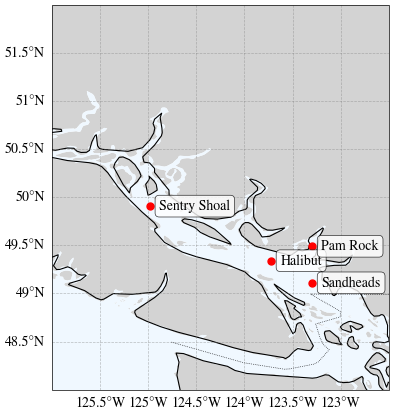

In [11]:
# Station locations

# lon and lats
stations = {
    'Halibut': {'lat': 49.34, 'lon': -123.727},
    'Sentry Shoal': {'lat': 49.907, 'lon': -124.985},
    'Pam Rock': {'lat': 49.49, 'lon': -123.3},
    'Sandheads': {'lat': 49.11, 'lon': -123.3}
}

# Modified from Toolbox

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import scienceplots  # 必须导入才能激活样式

# 使用 SciencePlots 的期刊样式
plt.style.use(['science', 'no-latex'])

# 创建画布
fig = plt.figure(figsize=(8, 5))

# 创建带有地图投影的子图 (这里使用最基础的等距圆柱投影)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# 添加地理特征 (这部分必须手动指定参数)
# 添加高分辨率岸线 (分辨率可选 '110m', '50m', '10m')
ax.coastlines(resolution='50m', linewidth=0.8, color='black')

# 添加陆地和海洋底色
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='none')
ax.add_feature(cfeature.OCEAN, facecolor='aliceblue')
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':') # 国界

# 绘制经纬度网格线 (SciencePlots 会影响这里的字体样式)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False   # 关闭顶部的经度标签
gl.right_labels = False # 关闭右侧的纬度标签

# Salish Sea region
ax.set_extent([-126.0, -122.5, 48, 52], crs=ccrs.PlateCarree())

bbox_props = dict(
        boxstyle='round,pad=0.3',    # 边框形状为圆角矩形，内衬（padding）为 0.3
        facecolor='white',            # 填充颜色为白色
        edgecolor='black',            # 边框颜色为黑色
        linewidth=0.5,                # 边框线条宽度
        alpha=0.8,                     # 整个文本框的透明度 (0-1)
    )

# Add annotation
for name, coords in stations.items():
    lon, lat = coords['lon'], coords['lat']
    
    # dots
    ax.plot(lon, lat, marker='o', color='red', markersize=5, transform=ccrs.PlateCarree())
    
    # station name
    ax.text(lon + 0.1, lat, name, transform=ccrs.PlateCarree(), fontsize=10, va='center',
            bbox=bbox_props)

plt.show()

### Sandheads

Copied from `Download & Inspection`

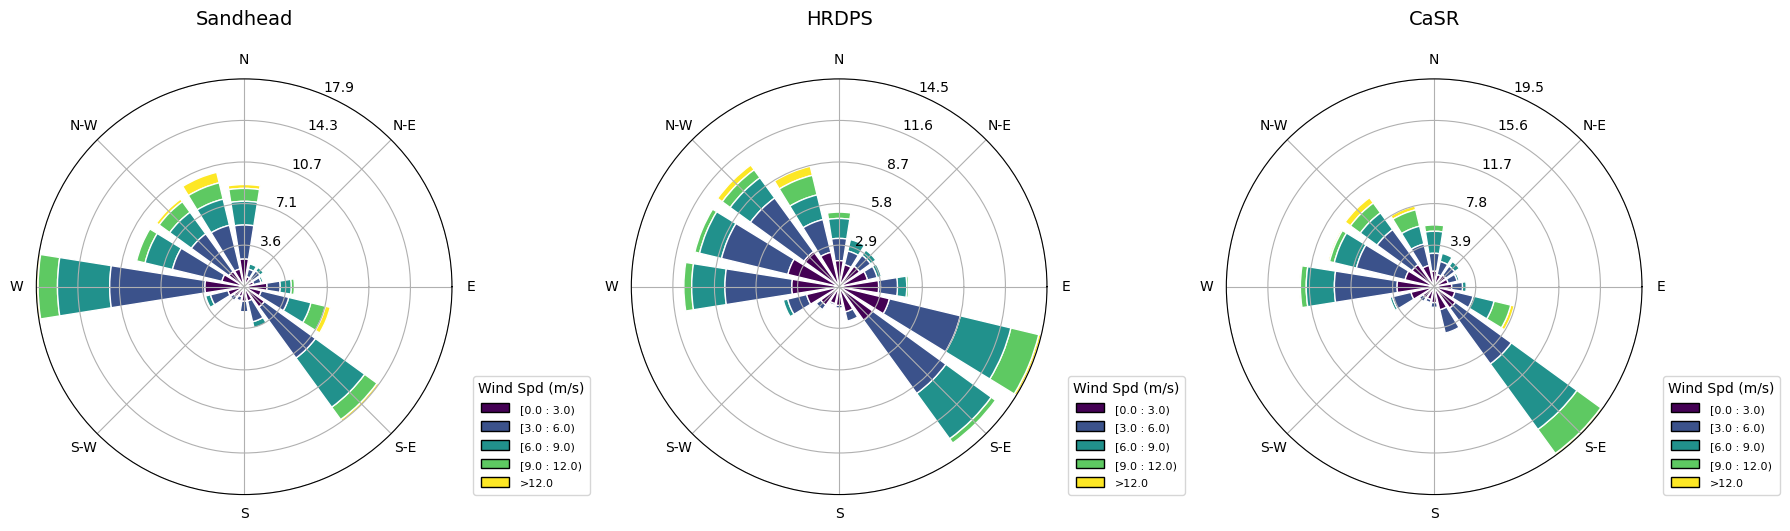

/tmp/ipykernel_154898/2666787188.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_mean = df.groupby('Obs_Bin')['Obs_Spd_ms'].mean()
/tmp/ipykernel_154898/2666787188.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  high_mean = df.groupby('High_Bin')['High_Spd_ms'].mean()
/tmp/ipykernel_154898/2666787188.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  low_mean = df.groupby('Low_Bin')['Low_Spd_ms'].mean()


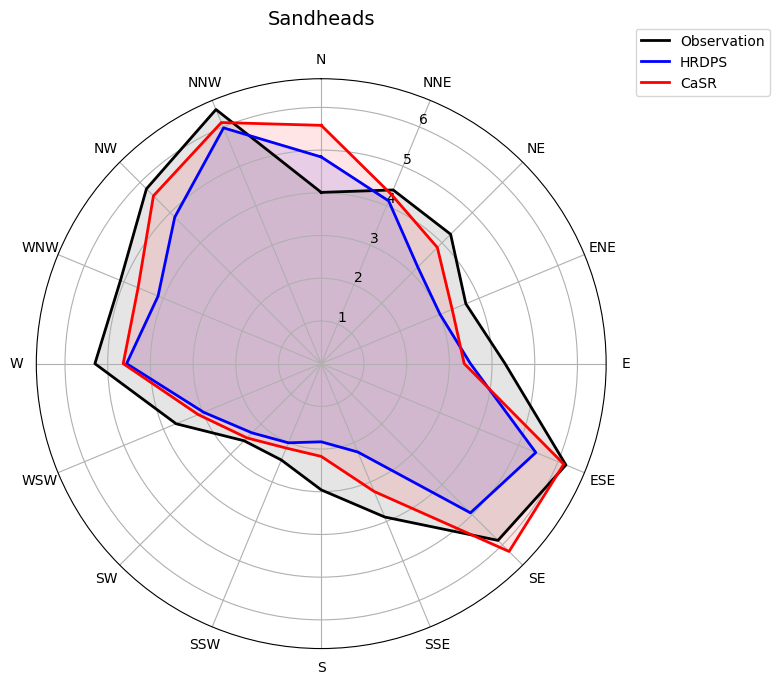

In [3]:
# Rose and Mean Speed

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from windrose import WindroseAxes

df = pd.read_csv('/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_model_vs_observation/Data_2018/Sandheads_wind_comparison_2018.csv', index_col='Time_UTC', parse_dates=True)

# Wind Rose, Blowing Towards

fig = plt.figure(figsize=(18, 6))

def plot_windrose(fig_obj, pos, spd, direct, title):
    valid_idx = ~np.isnan(spd) & ~np.isnan(direct)
    spd_valid = spd[valid_idx]
    dir_valid = direct[valid_idx]
    
    ax = fig_obj.add_subplot(1, 3, pos, projection="windrose")
    ax.bar(dir_valid, spd_valid, normed=True, opening=0.8, edgecolor='white', bins=np.arange(0, 15, 3))
    ax.set_title(title, pad=20, fontsize=14)
    ax.set_legend(title="Wind Spd (m/s)", loc=(1.05, 0))

plot_windrose(fig, 1, df['Obs_Spd_ms'], df['Obs_Dir_deg'], "Sandhead")
plot_windrose(fig, 2, df['High_Spd_ms'], df['High_Dir_deg'], "HRDPS")
plot_windrose(fig, 3, df['Low_Spd_ms'], df['Low_Dir_deg'], "CaSR")

plt.tight_layout()
# plt.savefig('Wind_Roses_Comparison.png', dpi=300)
plt.show()


# Polygon, Blowing Towards

bins = np.arange(-11.25, 360, 22.5)
labels = np.arange(0, 360, 22.5)

def categorize_direction(d):
    cat = pd.cut(d % 360, bins=bins, labels=labels, right=False)
    cat = cat.fillna(0.0)
    return cat

df['Obs_Bin'] = categorize_direction(df['Obs_Dir_deg'])
df['High_Bin'] = categorize_direction(df['High_Dir_deg'])
df['Low_Bin'] = categorize_direction(df['Low_Dir_deg'])

obs_mean = df.groupby('Obs_Bin')['Obs_Spd_ms'].mean()
high_mean = df.groupby('High_Bin')['High_Spd_ms'].mean()
low_mean = df.groupby('Low_Bin')['Low_Spd_ms'].mean()

angles = np.deg2rad(labels)
angles_closed = np.append(angles, angles[0])
obs_closed = np.append(obs_mean.values, obs_mean.values[0])
high_closed = np.append(high_mean.values, high_mean.values[0])
low_closed = np.append(low_mean.values, low_mean.values[0])

fig2, ax2 = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax2.set_theta_zero_location('N')
ax2.set_theta_direction(-1)

ax2.plot(angles_closed, obs_closed, label='Observation', linewidth=2, color='black')
ax2.fill(angles_closed, obs_closed, color='black', alpha=0.1)

ax2.plot(angles_closed, high_closed, label='HRDPS', linewidth=2, color='blue')
ax2.fill(angles_closed, high_closed, color='blue', alpha=0.1)

ax2.plot(angles_closed, low_closed, label='CaSR', linewidth=2, color='red')
ax2.fill(angles_closed, low_closed, color='red', alpha=0.1)



direction_names = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE', 'S', 'SSW', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW']
ax2.set_xticks(angles)
ax2.set_xticklabels(direction_names)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax2.set_title('Sandheads', pad=20, fontsize=14)

plt.tight_layout()
plt.show()

### Pam Rocks

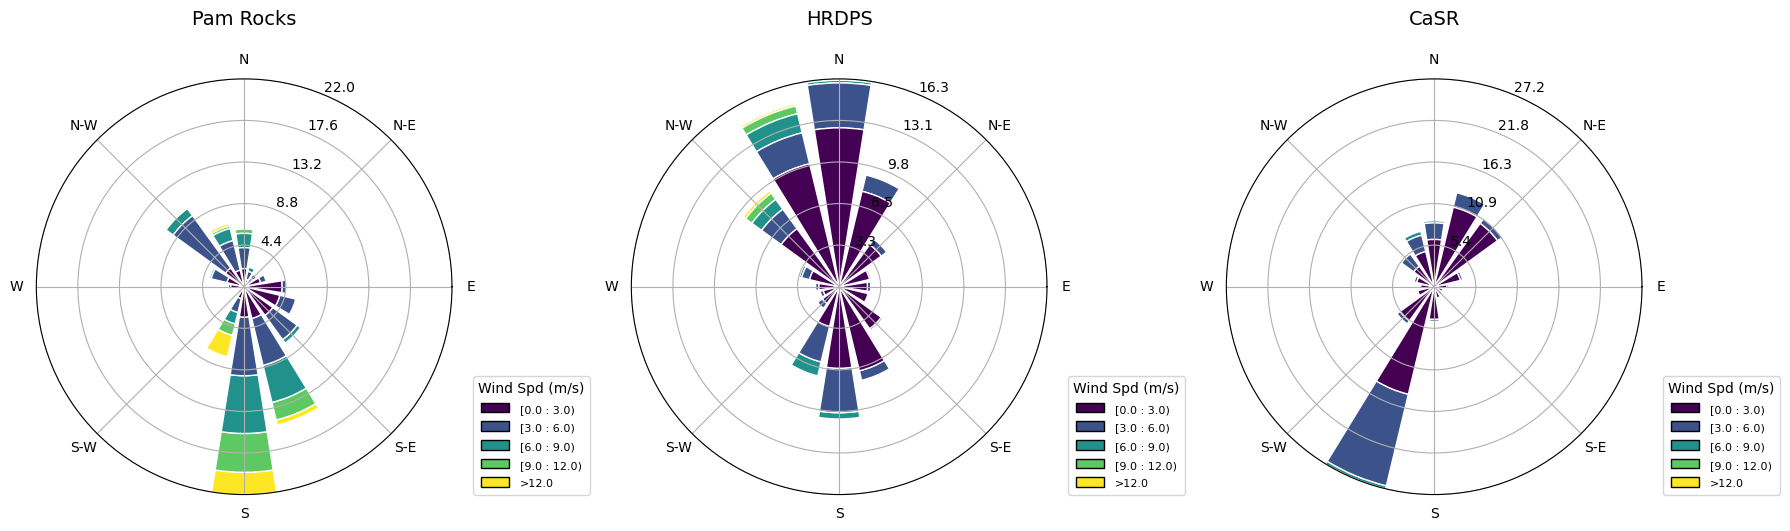

/tmp/ipykernel_154898/846650924.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_mean = df.groupby('Obs_Bin')['Obs_Spd_ms'].mean()
/tmp/ipykernel_154898/846650924.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  high_mean = df.groupby('High_Bin')['High_Spd_ms'].mean()
/tmp/ipykernel_154898/846650924.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  low_mean = df.groupby('Low_Bin')['Low_Spd_ms'].mean()


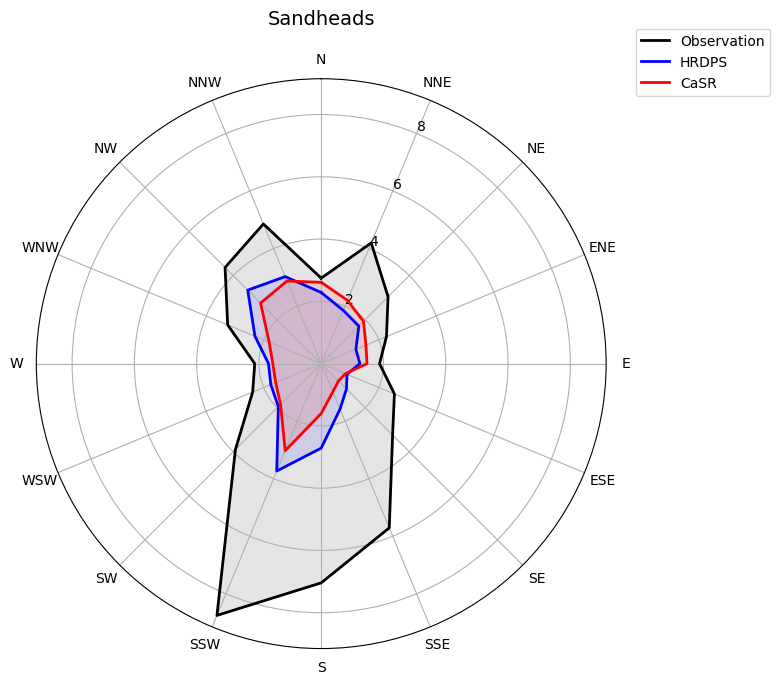

In [4]:
# Rose and Mean Speed

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from windrose import WindroseAxes

df = pd.read_csv('/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_model_vs_observation/Data_2018/PamRocks_wind_comparison_2018.csv', index_col='Time_UTC', parse_dates=True)

# Wind Rose, Blowing Towards

fig = plt.figure(figsize=(18, 6))

def plot_windrose(fig_obj, pos, spd, direct, title):
    valid_idx = ~np.isnan(spd) & ~np.isnan(direct)
    spd_valid = spd[valid_idx]
    dir_valid = direct[valid_idx]
    
    ax = fig_obj.add_subplot(1, 3, pos, projection="windrose")
    ax.bar(dir_valid, spd_valid, normed=True, opening=0.8, edgecolor='white', bins=np.arange(0, 15, 3))
    ax.set_title(title, pad=20, fontsize=14)
    ax.set_legend(title="Wind Spd (m/s)", loc=(1.05, 0))

plot_windrose(fig, 1, df['Obs_Spd_ms'], df['Obs_Dir_deg'], "Pam Rocks")
plot_windrose(fig, 2, df['High_Spd_ms'], df['High_Dir_deg'], "HRDPS")
plot_windrose(fig, 3, df['Low_Spd_ms'], df['Low_Dir_deg'], "CaSR")

plt.tight_layout()
# plt.savefig('Wind_Roses_Comparison.png', dpi=300)
plt.show()


# Polygon, Blowing Towards

bins = np.arange(-11.25, 360, 22.5)
labels = np.arange(0, 360, 22.5)

def categorize_direction(d):
    cat = pd.cut(d % 360, bins=bins, labels=labels, right=False)
    cat = cat.fillna(0.0)
    return cat

df['Obs_Bin'] = categorize_direction(df['Obs_Dir_deg'])
df['High_Bin'] = categorize_direction(df['High_Dir_deg'])
df['Low_Bin'] = categorize_direction(df['Low_Dir_deg'])

obs_mean = df.groupby('Obs_Bin')['Obs_Spd_ms'].mean()
high_mean = df.groupby('High_Bin')['High_Spd_ms'].mean()
low_mean = df.groupby('Low_Bin')['Low_Spd_ms'].mean()

angles = np.deg2rad(labels)
angles_closed = np.append(angles, angles[0])
obs_closed = np.append(obs_mean.values, obs_mean.values[0])
high_closed = np.append(high_mean.values, high_mean.values[0])
low_closed = np.append(low_mean.values, low_mean.values[0])

fig2, ax2 = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax2.set_theta_zero_location('N')
ax2.set_theta_direction(-1)

ax2.plot(angles_closed, obs_closed, label='Observation', linewidth=2, color='black')
ax2.fill(angles_closed, obs_closed, color='black', alpha=0.1)

ax2.plot(angles_closed, high_closed, label='HRDPS', linewidth=2, color='blue')
ax2.fill(angles_closed, high_closed, color='blue', alpha=0.1)

ax2.plot(angles_closed, low_closed, label='CaSR', linewidth=2, color='red')
ax2.fill(angles_closed, low_closed, color='red', alpha=0.1)



direction_names = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE', 'S', 'SSW', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW']
ax2.set_xticks(angles)
ax2.set_xticklabels(direction_names)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax2.set_title('Sandheads', pad=20, fontsize=14)

plt.tight_layout()
plt.show()

### Sentry Shoal

The following 2 data are from buoy. The processing can be slightly different.

In [ ]:
# Rose and Mean Speed

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from windrose import WindroseAxes

df_model = pd.read_csv('/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_model_vs_observation/Data_2018/Sentry_shoal_model_comparison.csv', index_col='Time_UTC', parse_dates=True)
df_obs = pd.read_csv('/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_model_vs_observation/Data_2018/Sentry_Shoal_2018_wind.csv', index_col='datetime_utc', parse_dates=True)

# Note that the dir in observation is wind-from. We convert it to wind-to directions.

In [2]:
df_model.head()

,High_Spd_ms,High_Dir_deg,Low_Spd_ms,Low_Dir_deg
Time_UTC,,,,
2018-01-01 00:00:00,0.324670,131.951110,1.816751,171.85620
2018-01-01 01:00:00,2.365930,125.355970,1.730856,153.45193
2018-01-01 02:00:00,1.901177,127.094710,1.836218,123.04663
2018-01-01 03:00:00,1.222238,147.314510,1.958921,109.21760
2018-01-01 04:00:00,1.064187,127.084854,1.706344,109.98796


In [7]:
df_obs.head()

,WDIR,WSPD
datetime_utc,,
2018-01-01 00:32:00+00:00,324.0,2.3
2018-01-01 01:32:00+00:00,325.0,2.6
2018-01-01 02:32:00+00:00,344.0,3.4
2018-01-01 03:32:00+00:00,321.0,3.9
2018-01-01 04:32:00+00:00,315.0,2.9


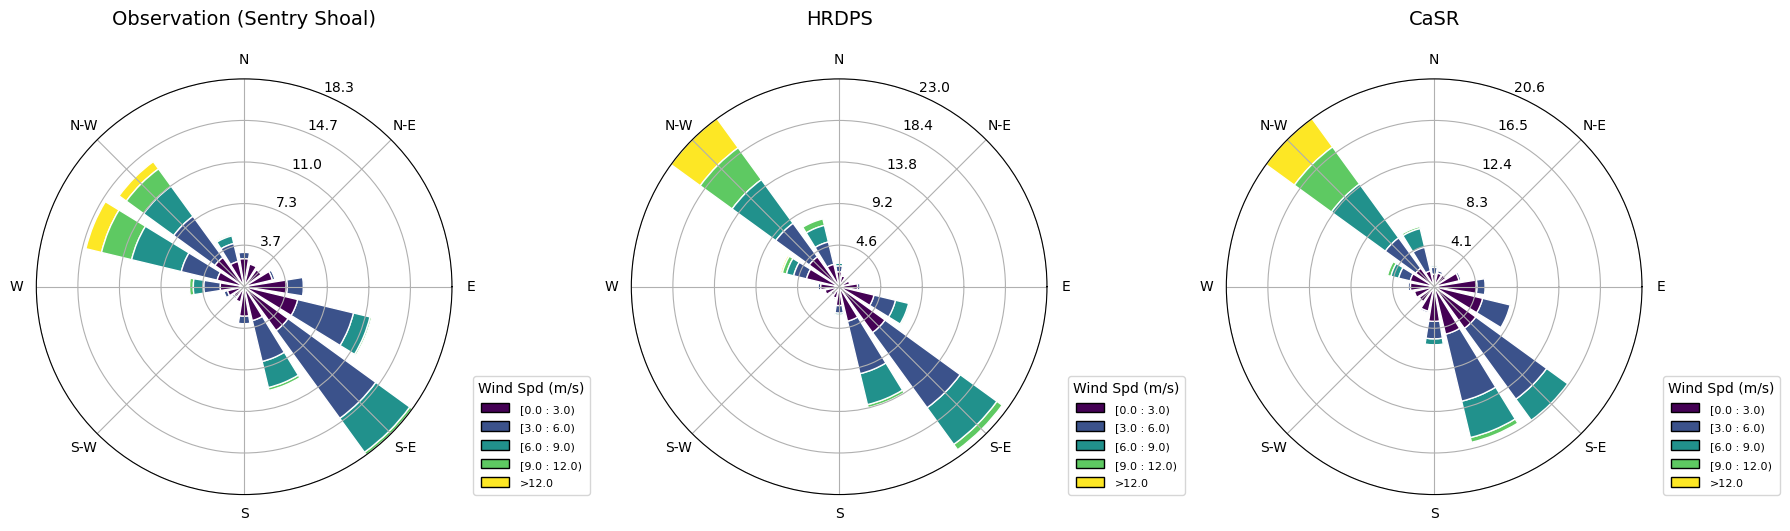

/tmp/ipykernel_217140/2802932324.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_mean = df_obs.groupby('Obs_Bin')['WSPD'].mean()
/tmp/ipykernel_217140/2802932324.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  high_mean = df_model.groupby('High_Bin')['High_Spd_ms'].mean()
/tmp/ipykernel_217140/2802932324.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  low_mean = df_model.groupby('Low_Bin')['Low_Spd_ms'

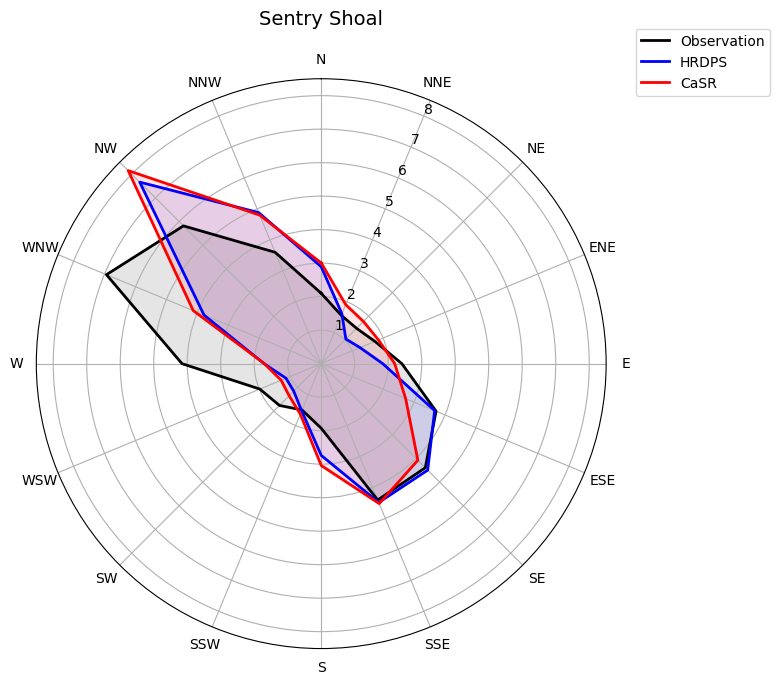

In [8]:
# Rose and Mean Speed

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from windrose import WindroseAxes

# read
df_model = pd.read_csv('/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_model_vs_observation/Data_2018/Sentry_shoal_model_comparison.csv', index_col='Time_UTC', parse_dates=True)
df_obs = pd.read_csv('/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_model_vs_observation/Data_2018/Sentry_Shoal_2018_wind.csv', index_col='datetime_utc', parse_dates=True)

# convert wind-from to wind-to
df_obs['WDIR_to'] = (df_obs['WDIR'] + 180) % 360


# Wind Rose, Blowing Towards


fig = plt.figure(figsize=(18, 6))

def plot_windrose(fig_obj, pos, spd, direct, title):
    valid_idx = ~np.isnan(spd) & ~np.isnan(direct)
    spd_valid = spd[valid_idx]
    dir_valid = direct[valid_idx]
    
    ax = fig_obj.add_subplot(1, 3, pos, projection="windrose")
    ax.bar(dir_valid, spd_valid, normed=True, opening=0.8, edgecolor='white', bins=np.arange(0, 15, 3))
    ax.set_title(title, pad=20, fontsize=14)
    ax.set_legend(title="Wind Spd (m/s)", loc=(1.05, 0))


plot_windrose(fig, 1, df_obs['WSPD'], df_obs['WDIR_to'], "Observation (Sentry Shoal)")
plot_windrose(fig, 2, df_model['High_Spd_ms'], df_model['High_Dir_deg'], "HRDPS")
plot_windrose(fig, 3, df_model['Low_Spd_ms'], df_model['Low_Dir_deg'], "CaSR")

plt.tight_layout()
# plt.savefig('Wind_Roses_Comparison.png', dpi=300)
plt.show()

# Polygon, Blowing Towards


bins = np.arange(-11.25, 360, 22.5)
labels = np.arange(0, 360, 22.5)

def categorize_direction(d):
    cat = pd.cut(d % 360, bins=bins, labels=labels, right=False)
    cat = cat.fillna(0.0)
    return cat

# bin
df_obs['Obs_Bin'] = categorize_direction(df_obs['WDIR_to'])
df_model['High_Bin'] = categorize_direction(df_model['High_Dir_deg'])
df_model['Low_Bin'] = categorize_direction(df_model['Low_Dir_deg'])

# average
obs_mean = df_obs.groupby('Obs_Bin')['WSPD'].mean()
high_mean = df_model.groupby('High_Bin')['High_Spd_ms'].mean()
low_mean = df_model.groupby('Low_Bin')['Low_Spd_ms'].mean()

angles = np.deg2rad(labels)
angles_closed = np.append(angles, angles[0])
obs_closed = np.append(obs_mean.values, obs_mean.values[0])
high_closed = np.append(high_mean.values, high_mean.values[0])
low_closed = np.append(low_mean.values, low_mean.values[0])

fig2, ax2 = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax2.set_theta_zero_location('N')
ax2.set_theta_direction(-1)

ax2.plot(angles_closed, obs_closed, label='Observation', linewidth=2, color='black')
ax2.fill(angles_closed, obs_closed, color='black', alpha=0.1)

ax2.plot(angles_closed, high_closed, label='HRDPS', linewidth=2, color='blue')
ax2.fill(angles_closed, high_closed, color='blue', alpha=0.1)

ax2.plot(angles_closed, low_closed, label='CaSR', linewidth=2, color='red')
ax2.fill(angles_closed, low_closed, color='red', alpha=0.1)

direction_names = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE', 'S', 'SSW', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW']
ax2.set_xticks(angles)
ax2.set_xticklabels(direction_names)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax2.set_title('Sentry Shoal', pad=20, fontsize=14)

plt.tight_layout()
plt.show()

### Halibut

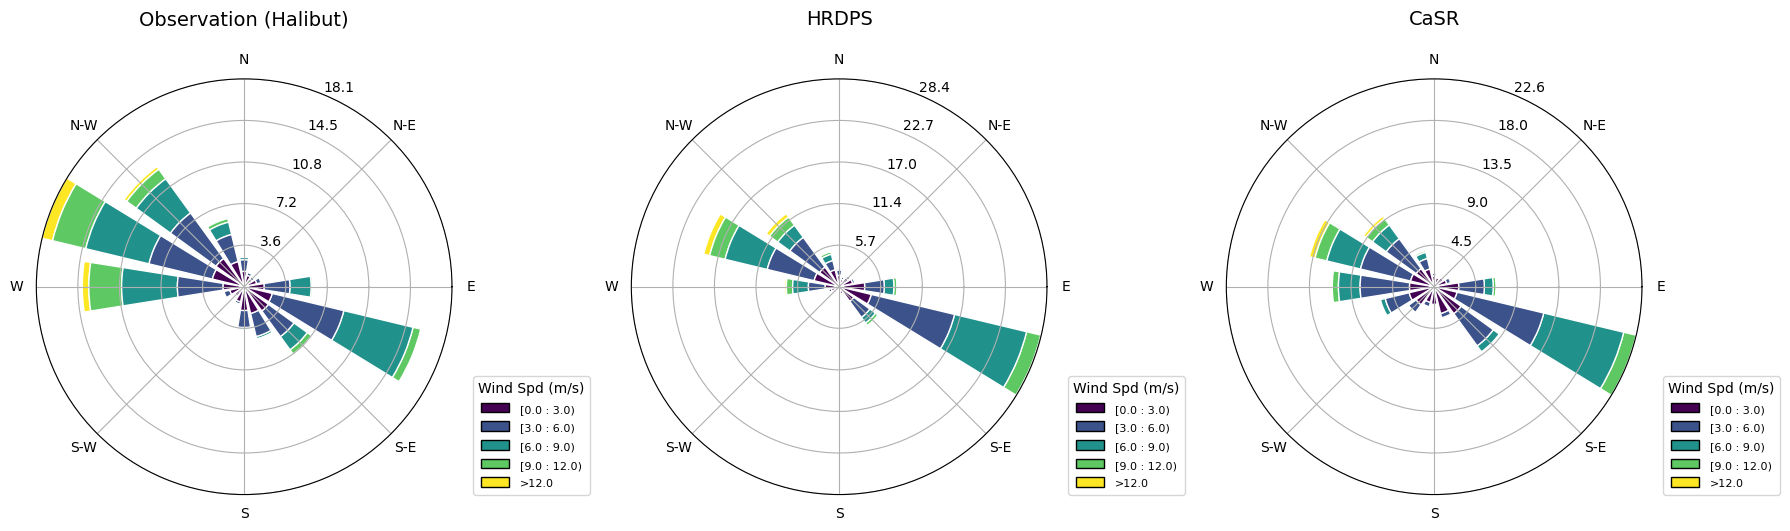

/tmp/ipykernel_217140/1457997022.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_mean = df_obs.groupby('Obs_Bin')['WSPD'].mean()
/tmp/ipykernel_217140/1457997022.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  high_mean = df_model.groupby('High_Bin')['High_Spd_ms'].mean()
/tmp/ipykernel_217140/1457997022.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  low_mean = df_model.groupby('Low_Bin')['Low_Spd_ms'

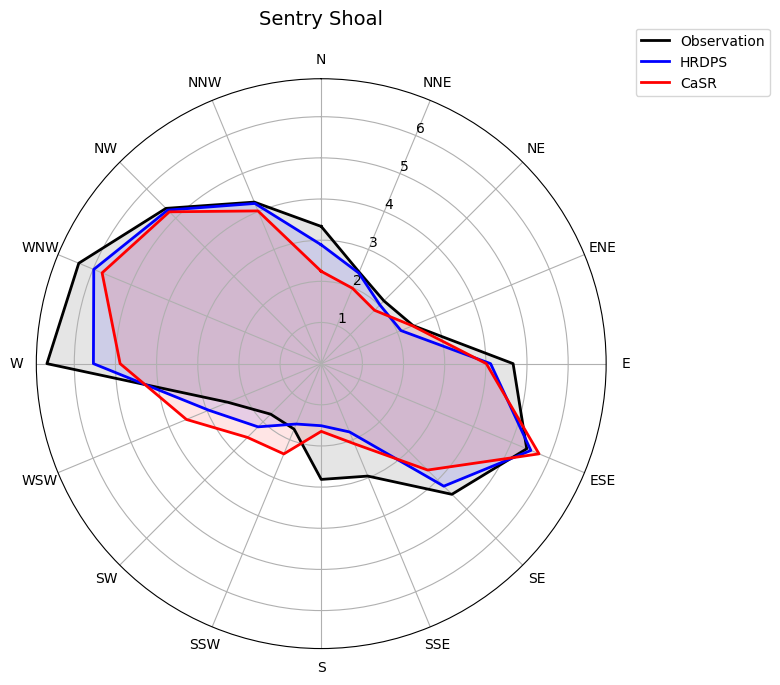

In [9]:
# Rose and Mean Speed

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from windrose import WindroseAxes

# read
df_model = pd.read_csv('/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_model_vs_observation/Data_2018/Halibut_model_comparison.csv', index_col='Time_UTC', parse_dates=True)
df_obs = pd.read_csv('/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_model_vs_observation/Data_2018/Halibut_2018_wind.csv', index_col='datetime_utc', parse_dates=True)

# convert wind-from to wind-to
df_obs['WDIR_to'] = (df_obs['WDIR'] + 180) % 360


# Wind Rose, Blowing Towards


fig = plt.figure(figsize=(18, 6))

def plot_windrose(fig_obj, pos, spd, direct, title):
    valid_idx = ~np.isnan(spd) & ~np.isnan(direct)
    spd_valid = spd[valid_idx]
    dir_valid = direct[valid_idx]
    
    ax = fig_obj.add_subplot(1, 3, pos, projection="windrose")
    ax.bar(dir_valid, spd_valid, normed=True, opening=0.8, edgecolor='white', bins=np.arange(0, 15, 3))
    ax.set_title(title, pad=20, fontsize=14)
    ax.set_legend(title="Wind Spd (m/s)", loc=(1.05, 0))


plot_windrose(fig, 1, df_obs['WSPD'], df_obs['WDIR_to'], "Observation (Halibut)")
plot_windrose(fig, 2, df_model['High_Spd_ms'], df_model['High_Dir_deg'], "HRDPS")
plot_windrose(fig, 3, df_model['Low_Spd_ms'], df_model['Low_Dir_deg'], "CaSR")

plt.tight_layout()
# plt.savefig('Wind_Roses_Comparison.png', dpi=300)
plt.show()

# Polygon, Blowing Towards


bins = np.arange(-11.25, 360, 22.5)
labels = np.arange(0, 360, 22.5)

def categorize_direction(d):
    cat = pd.cut(d % 360, bins=bins, labels=labels, right=False)
    cat = cat.fillna(0.0)
    return cat

# bin
df_obs['Obs_Bin'] = categorize_direction(df_obs['WDIR_to'])
df_model['High_Bin'] = categorize_direction(df_model['High_Dir_deg'])
df_model['Low_Bin'] = categorize_direction(df_model['Low_Dir_deg'])

# average
obs_mean = df_obs.groupby('Obs_Bin')['WSPD'].mean()
high_mean = df_model.groupby('High_Bin')['High_Spd_ms'].mean()
low_mean = df_model.groupby('Low_Bin')['Low_Spd_ms'].mean()

angles = np.deg2rad(labels)
angles_closed = np.append(angles, angles[0])
obs_closed = np.append(obs_mean.values, obs_mean.values[0])
high_closed = np.append(high_mean.values, high_mean.values[0])
low_closed = np.append(low_mean.values, low_mean.values[0])

fig2, ax2 = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax2.set_theta_zero_location('N')
ax2.set_theta_direction(-1)

ax2.plot(angles_closed, obs_closed, label='Observation', linewidth=2, color='black')
ax2.fill(angles_closed, obs_closed, color='black', alpha=0.1)

ax2.plot(angles_closed, high_closed, label='HRDPS', linewidth=2, color='blue')
ax2.fill(angles_closed, high_closed, color='blue', alpha=0.1)

ax2.plot(angles_closed, low_closed, label='CaSR', linewidth=2, color='red')
ax2.fill(angles_closed, low_closed, color='red', alpha=0.1)

direction_names = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE', 'S', 'SSW', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW']
ax2.set_xticks(angles)
ax2.set_xticklabels(direction_names)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax2.set_title('Sentry Shoal', pad=20, fontsize=14)

plt.tight_layout()
plt.show()

### Extra explanation

The idea of the plots comes from Foreman et al. (2024)'s *A Circulation Model for Inlets Along the Central West Coast of Vancouver Island*. The direction of the wind is **towards** where the wind is blowing and polygons denote the average speed instead of wind frequency. Further change may be required if necessary.

**Foreman's caption:**

    Fig.10 East-west and north-south components of the wind (m s−1) (left column) and wind roses (right column) at the Saranac Island farm for the period of 23  May to 31 August 2019. Row (a) shows the east-west and north-south components of the observations and the associated wind rose, while rows (b) and (c) are similar but for the HRDPS atmospheric models with 2.5 and 1.0 km horizontal resolution, respectively. Percent wind rose directions denote to where the wind is blowing while the polygons denote the average speed in each direction.

## Frequency 

### Sandheads frequency 

In [17]:

# Sandheads frequency analysis
# fft codes from https://zhuanlan.zhihu.com/p/366455271

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_sh = pd.read_csv('/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_model_vs_observation/Data_2018/Sandheads_wind_comparison_2018.csv')

time_sh=df_sh['Time_UTC']
wind_obs_sh=df_sh['Obs_Spd_ms'].interpolate()
wind_hrdps_sh=df_sh['High_Spd_ms'].interpolate()
wind_casr_sh=df_sh['Low_Spd_ms'].interpolate()

# fft
from scipy.fft import fft, fftfreq


N = len(wind_obs_sh)
dt = 1.0 # hourly data

# demean and run fft

# hanning window? see https://numpy.org/doc/2.3/reference/generated/numpy.hanning.html

f_obs_sh=fft((wind_obs_sh-np.mean(wind_obs_sh))*np.hanning(N))
f_hrdps_sh=fft((wind_hrdps_sh-np.mean(wind_hrdps_sh))*np.hanning(N))
f_casr_sh=fft((wind_casr_sh-np.mean(wind_casr_sh))*np.hanning(N))

# frequency axis
xf=fftfreq(N,dt)
xf=xf[:N//2]

# calculate amplitude

amp_obs = 2.0 / N * np.abs(f_obs_sh[:N//2])
amp_hrdps = 2.0 / N * np.abs(f_hrdps_sh[:N//2])
amp_casr = 2.0 / N * np.abs(f_casr_sh[:N//2])



/tmp/ipykernel_1691346/2131724097.py:24: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 0.5)


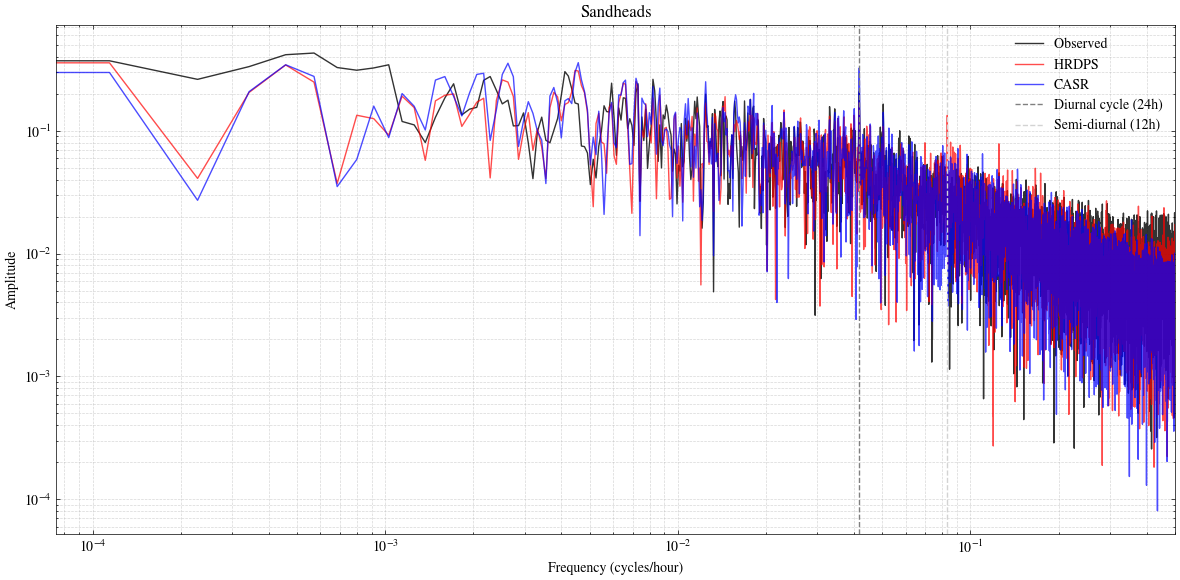

In [18]:
# visualization

import scienceplots

plt.style.use(['science', 'no-latex'])

plt.figure(figsize=(12, 6))


# use plt.loglog
plt.loglog(xf, amp_obs, label='Observed ', alpha=0.8, color='black')
plt.loglog(xf, amp_hrdps, label='HRDPS ', alpha=0.7, color='red')
plt.loglog(xf, amp_casr, label='CASR', alpha=0.7, color='blue')

# daily = 1/24 
plt.axvline(x=1/24, color='gray', linestyle='--', label='Diurnal cycle (24h)')
plt.axvline(x=1/12, color='lightgray', linestyle='--', label='Semi-diurnal (12h)')

plt.title('Sandheads')
plt.xlabel('Frequency (cycles/hour)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.xlim(0, 0.5) 

plt.tight_layout()
plt.show()

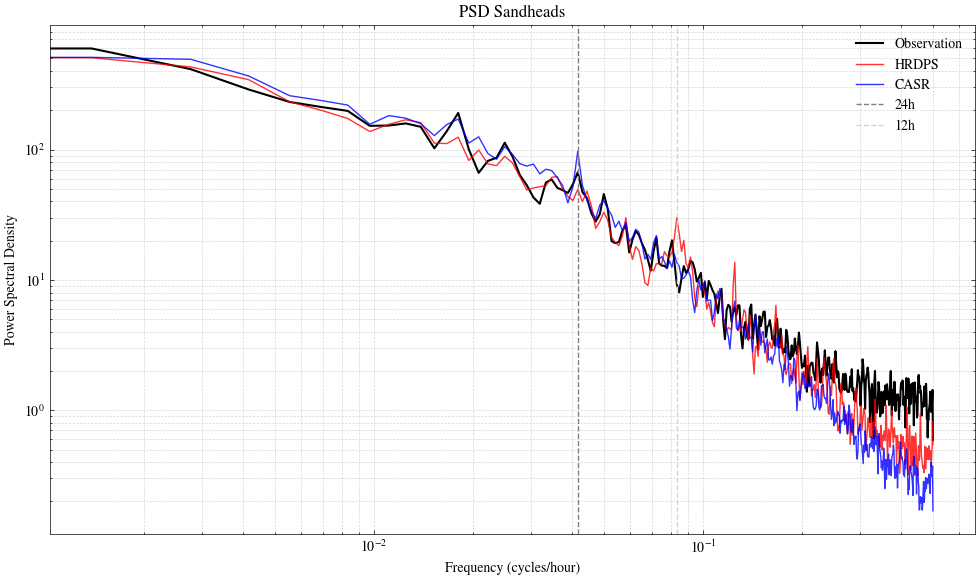

In [20]:
# Try PSD
# see https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.welch.html for Welch's methods

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal # 引入 signal 模块


df_sh = pd.read_csv('/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_model_vs_observation/Data_2018/Sandheads_wind_comparison_2018.csv')

wind_obs_sh = df_sh['Obs_Spd_ms'].interpolate().values
wind_hrdps_sh = df_sh['High_Spd_ms'].interpolate().values
wind_casr_sh = df_sh['Low_Spd_ms'].interpolate().values

fs = 1.0 # 1 sample / hour



n_window = 24 * 30 # 720-hour window

freqs, psd_obs = signal.welch(wind_obs_sh, fs=fs, window='hann', detrend='constant', nperseg=n_window)
_, psd_hrdps = signal.welch(wind_hrdps_sh, fs=fs, window='hann', detrend='constant', nperseg=n_window)
_, psd_casr = signal.welch(wind_casr_sh, fs=fs, window='hann', detrend='constant', nperseg=n_window)

# visualization
import scienceplots
plt.style.use(['science', 'no-latex'])
plt.figure(figsize=(10, 6))

# loglog 
plt.loglog(freqs, psd_obs, label='Observation', color='black', linewidth=1.5)
plt.loglog(freqs, psd_hrdps, label='HRDPS', color='red', alpha=0.8)
plt.loglog(freqs, psd_casr, label='CASR', color='blue', alpha=0.8)

# daily and half-daily
plt.axvline(1/24, color='gray', linestyle='--', label='24h')
plt.axvline(1/12, color='lightgray', linestyle='--', label='12h')

plt.title('PSD Sandheads')
plt.xlabel('Frequency (cycles/hour)')
plt.ylabel('Power Spectral Density')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()